# 使用PROC GPROJECT为地图投影临床试验中心坐标

## 摘要

一个临床运营团队需要在平面地图上绘制一项多中心III期试验的地理分布。本笔记本
为围绕五个美国区域枢纽聚集的试验中心生成合成的经纬度坐标，然后使用
**PROC GPROJECT**通过三种投影方法（Albers等积投影、带自定义标准纬线和区域
裁剪的Lambert等角投影，以及以美国大陆为中心的Gnomonic投影）将球面坐标转换
为笛卡尔X/Y坐标值，展示投影方式和裁剪如何影响中心地图。

## 数据来源

| 数据集 | 行数 | 关键变量 | 说明 |
|---------|------|---------------|-------------|
| `trial_sites` | 60（5个枢纽 x 12个中心） | `site_id`（$8 ID）、`region`（$9）、`x`（经度，单位为度，东正）、`y`（纬度，单位为度）、`enroll`（入组受试者数）、`segment`（地图分段编号） | 使用`rand('normal')`扰动和`rand('poisson')`入组人数，围绕五个美国区域枢纽（西部、中西部、东北部、南部、东南部）散布生成的合成III期临床试验中心位置 |

# 使用PROC GPROJECT投影临床试验中心坐标

当申办方开展一项地理上分散的III期试验时，临床运营团队通常希望绘制一张地图，
展示每一个研究中心，并按入组人数调整大小或着色。中心位置以**经度/纬度坐标对**
的形式给出，但平面地图需要**平面X/Y坐标**。`PROC GPROJECT`执行这一球面到
笛卡尔坐标的转换，应用制图投影使距离和面积能够被合理地呈现。

在本笔记本中我们将：

1. 生成围绕五个美国区域枢纽聚集的合成中心坐标。
2. 应用默认的**Albers等积**投影。
3. 应用带自定义标准纬线的**Lambert等角**投影，并裁剪到美国本土。
4. 应用以国家地理中心为中心的**Gnomonic**投影，并使用`ASIS`保留原始坐标。

一切均为自包含：无外部文件，无需联网。

## 步骤1 — 生成合成试验中心坐标

我们用`call streaminit`为随机数生成器设置种子以保证可复现性，然后在五个
区域枢纽城市各自周围放置12个中心。经度以东正的度数存储（西半球为负值），
纬度以度数存储。每一行还携带一个入组人数和一个`segment`变量（GPROJECT
在投影过程中会保留非坐标列）。

In [1]:
数据 trial_sites;
    调用 streaminit(20260531);
    长度 site_id $8 region $15;
    /* 五个美国区域枢纽中心：经度（东正）、纬度 */
    数组 clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    数组 clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    循环 hub = 1 到 5;
        如果 hub = 1 那么 region = '西部';
        否则 如果 hub = 2 那么 region = '中西部';
        否则 如果 hub = 3 那么 region = '东北部';
        否则 如果 hub = 4 那么 region = '南部';
        否则 region = '东南部';
        循环 s = 1 到 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* 经度，度 */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* 纬度，度 */
            enroll  = round(rand('poisson', 60));           /* 入组受试者数 */
            segment = 1;
            输出;
        结束;
    结束;
    删除 hub s;
运行;

过程 打印 数据=trial_sites(obs=10) 标签;
    标签 site_id="中心编号" region="区域" x="经度(X)" y="纬度(Y)"
          enroll="入组人数" segment="分段";
    标题 "合成临床试验中心样本（未投影经纬度）";
运行;

                                                   合成临床试验中心样本（未投影经纬度）                                                   

  Obs          中心编号      区域            经度(X)          纬度(Y)          入组人数      分段
    1  S101          西部      -121.6437232216  37.7677668495            65       1
    2  S102          西部      -120.7384024716  37.5083287903            61       1
    3  S103          西部      -121.5133780284  37.8633933883            72       1
    4  S104          西部      -121.2086817368  38.7723343392            68       1
    5  S105          西部      -121.0499572297   37.175813806            54       1
    6  S106          西部      -124.0531899967   35.778231667            72       1
    7  S107          西部      -120.9370181032  39.0576714397            64       1
    8  S108          西部      -126.8495029747  36.6474680375            55       1
    9  S109          西部       -123.475989897  37.1427965254            56       1
   10  S110          西部       -122.579780071   36.93153367


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## 步骤2 — 默认Albers等积投影

**Albers**等积圆锥投影是GPROJECT的默认投影，适用于需要保持*相对面积*
（例如比较各区域覆盖范围大小）的国家级地图。

由于我们的坐标以**度**存储，且**经度为东正**，因此指定`DEGREE`和
`EASTLONG`选项。`ID`语句指明用于唯一标识每个单元的变量；投影后的平面
坐标会写回`OUT=`数据集中的`x`和`y`。

In [2]:
过程 GPROJECT 数据=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
运行;

过程 打印 数据=sites_albers(obs=10) 标签;
    标签 site_id="中心编号" region="区域" x="投影X坐标" y="投影Y坐标"
          enroll="入组人数" segment="分段";
    标题 "Albers等积投影后的试验中心（平面X/Y坐标）";
运行;

                                                   合成临床试验中心样本（未投影经纬度）                                                   

                                               Albers等积投影后的试验中心（平面X/Y坐标）                                                

  Obs          中心编号      区域          投影X坐标          投影Y坐标          入组人数      分段
    1  S101          西部       -0.346124731   0.0516986079            65       1
    2  S102          西部      -0.3353644139   0.0440400181            61       1
    3  S103          西部      -0.3439609675   0.0528501365            72       1
    4  S104          西部      -0.3357513354    0.067213083            68       1
    5  S105          西部      -0.3410170723   0.0394882801            54       1
    6  S106          西部      -0.3879364507   0.0273340733            72       1
    7  S107          西部      -0.3309127579   0.0711146305            64       1
    8  S108          西部      -0.4204191205   0.0538118922            55       1
    9  S109          西部       -0.373


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## 步骤3 — 带自定义标准纬线和裁剪的Lambert等角投影

**Lambert等角**圆锥投影保持*形状和局部角度*，当地图用于导航或叠加方向性
要素时更为适合。对于美国本土，通常采用北纬33度和45度附近作为标准纬线，
因此我们用`PARALLEL1=`和`PARALLEL2=`显式设置它们。

我们还使用裁剪选项`LATMIN=`、`LATMAX=`、`LONGMIN=`和`LONGMAX=`将地图
限制在美国本土窗口范围内。任何落在此经纬度范围之外的中心都会在投影前
被丢弃，因此输出观测数可能低于输入观测数。

In [3]:
过程 GPROJECT 数据=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
运行;

过程 打印 数据=sites_lambert(obs=10) 标签;
    标签 site_id="中心编号" region="区域" x="投影X坐标" y="投影Y坐标"
          enroll="入组人数" segment="分段";
    标题 "Lambert等角投影后的试验中心（裁剪至美国本土）";
运行;

                                               Albers等积投影后的试验中心（平面X/Y坐标）                                                

                                               Lambert等角投影后的试验中心（裁剪至美国本土）                                               

  Obs          中心编号      区域          投影X坐标          投影Y坐标          入组人数      分段
    1  S101          西部      -0.3473024124   0.0279382533            65       1
    2  S102          西部      -0.3365626234   0.0201991247            61       1
    3  S103          西部      -0.3451238364   0.0290365995            72       1
    4  S104          西部      -0.3367881094   0.0430616123            68       1
    5  S105          西部      -0.3422656751   0.0158037156            54       1
    6  S106          西部      -0.3894389642   0.0046370991            72       1
    7  S107          西部      -0.3319086764   0.0468276119            64       1
    8  S109          西部      -0.3746144745   0.0248234546            56       1
    9  S110          西部      -0.3638


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## 步骤4 — 以国家为中心的Gnomonic投影，保留原始坐标

**Gnomonic**方位投影将每一条大圆弧都渲染为直线，当你需要推算中心之间的
最短路径时（例如规划监查员的中心访视行程路线）非常有用。畸变程度随着
距投影极点的距离增大而增大，因此我们用`POLELAT=39`和`POLELONG=-98`将
极点设在美国大陆的地理中心。

`ASIS`选项告诉GPROJECT在保留投影值的同时保留原始未投影坐标，因此输出
数据集同时携带平面`X`/`Y`和原始的`LONG`/`LAT`——便于将入组指标关联回
任一坐标空间。

`PARMENTRY`语句展示了以key=value形式覆盖提供投影参数的另一种方式。

In [4]:
过程 GPROJECT 数据=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
运行;

过程 打印 数据=sites_gnomon(obs=10) 标签;
    标签 site_id="中心编号" region="区域" x="投影X坐标" y="投影Y坐标"
          enroll="入组人数" segment="分段" long="原始经度" lat="原始纬度";
    标题 "Gnomonic投影后的试验中心（ASIS保留原始经纬度）";
运行;

                                               Lambert等角投影后的试验中心（裁剪至美国本土）                                               

                                             Gnomonic投影后的试验中心（ASIS保留原始经纬度）                                              

  Obs          中心编号      区域          投影X坐标          投影Y坐标          入组人数      分段             原始经度           原始纬度
    1  S101          西部      -0.3343477981   0.0213614461            65       1  -121.6437232216  37.7677668495
    2  S102          西部      -0.3221611694   0.0134152735            61       1  -120.7384024716  37.5083287903
    3  S103          西部      -0.3319480803   0.0225717184            72       1  -121.5133780284  37.8633933883
    4  S104          西部      -0.3230855797   0.0375741352            68       1  -121.2086817368  38.7723343392
    5  S105          西部      -0.3283677206   0.0086308769            54       1  -121.0499572297   37.175813806
    6  S106          西部      -0.3813558012  -0.0046248781            72       1  -12


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## 步骤5 — 渲染投影后的中心地图

投影的全部意义就在于绘制地图。我们将Albers投影得到的`OUT=`数据集直接
输入**PROC SGPLOT**，绘制平面`X`/`Y`坐标，并按`region`为每个标记着色。
由于投影保留了相对地理关系，五个枢纽集群落在图中各自预期的角落——
西部（West）在左侧，东北部（Northeast）在右上方，南部（South）和
东南部（Southeast）沿底部分布——为临床运营团队呈现了摘要中所述的
面积保真分布图。

                                             Gnomonic投影后的试验中心（ASIS保留原始经纬度）                                              




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


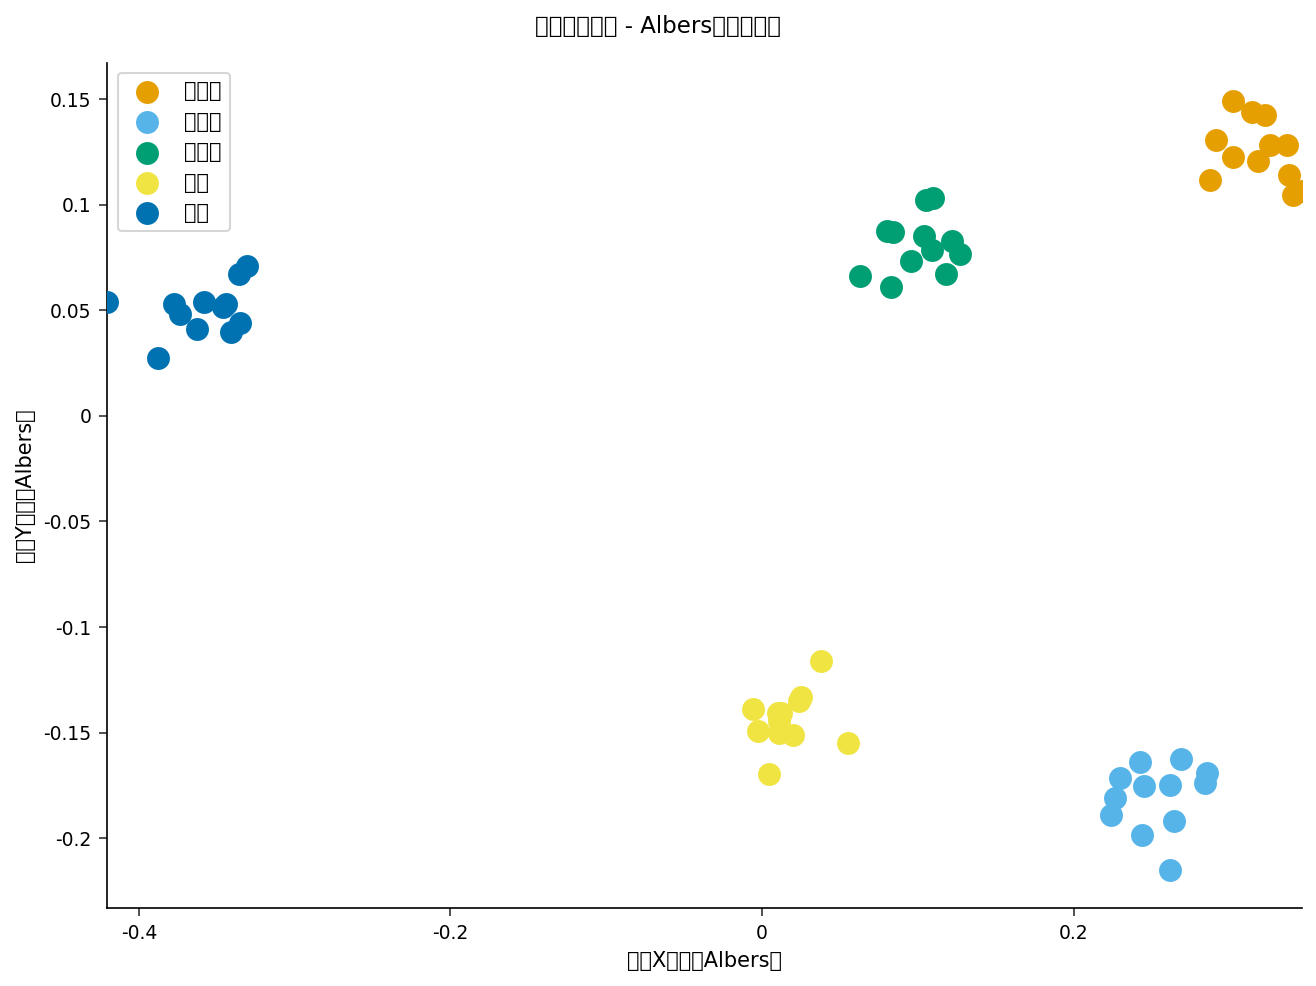

In [5]:
过程 SGPLOT 数据=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS 标签="投影X坐标（Albers）";
    YAXIS 标签="投影Y坐标（Albers）";
    标题 "临床试验中心 - Albers投影分布图";
运行;

## 结果解读

- **Albers（步骤2）**将全部60个中心转换为平面坐标，同时保持了相对面积——
  西部（West）、中西部（Midwest）、东北部（Northeast）、南部（South）和
  东南部（Southeast）各集群保持了其比例空间分布，这正是面积保真入组
  热力图所需的正确基础。
- **带裁剪的Lambert（步骤3）**保持了局部形状，并通过应用`LATMIN`/
  `LATMAX`/`LONGMIN`/`LONGMAX`窗口，丢弃了散布在美国本土之外的合成
  中心——此处观测数从60降到58，那两个原本会拉伸地图的越界坐标在投影前
  被移除。
- **带`ASIS`的Gnomonic（步骤4）**将投影中心设在国家内部，并借助`ASIS`
  生成了同时携带投影后`X`/`Y`和原始`LONG`/`LAT`的数据集。大圆弧在图中
  呈现为直线，因此该地图上的直线距离近似于中心之间的真实最短路径。
- **渲染后的分布图（步骤5）**证实了投影的效果：按`region`绘制Albers的
  `X`/`Y`坐标，将五个枢纽集群置于平面中各自预期的角落，正是摘要中所
  承诺的面积保真中心地图。

**给临床运营团队的启示：** 投影绝非装饰性步骤。当需要面积保真的入组
密度时选择**Albers**；当需要带区域裁剪的形状保真叠加图时选择
**Lambert**；当分析以中心间的行程距离为驱动因素时选择**Gnomonic**。
如步骤5所示，投影后的`OUT=`数据集可以直接输入PROC SGPLOT（或PROC GMAP）
来渲染最终的中心地图。